# StellerNet — EDA & Baseline Models

This notebook performs exploratory data analysis and builds baseline models for exoplanet detection.

**Sections:**
- Data loading and quick inspection
- Visualization of example light curves
- Preprocessing and feature preparation
- Baseline classical ML models and diagnostics
- Notes and motivation for deep learning approaches

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


# Load dataset
train = pd.read_csv("/Users/madhavkapoor/Desktop/StellerNet/data/exoplanet/exoTrain.csv")

train.head()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,2,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,2,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,2,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54


## Quick data overview

In [3]:
print("Shape:", train.shape)
print("\nColumns:", train.columns[:5], "...")

train.info()

Shape: (5087, 3198)

Columns: Index(['LABEL', 'FLUX.1', 'FLUX.2', 'FLUX.3', 'FLUX.4'], dtype='object') ...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5087 entries, 0 to 5086
Columns: 3198 entries, LABEL to FLUX.3197
dtypes: float64(3197), int64(1)
memory usage: 124.1 MB


In [4]:
train['LABEL'].value_counts()

LABEL
1    5050
2      37
Name: count, dtype: int64

In [5]:
X = train.drop("LABEL", axis=1)
y = train["LABEL"]

print(X.shape, y.shape)

(5087, 3197) (5087,)


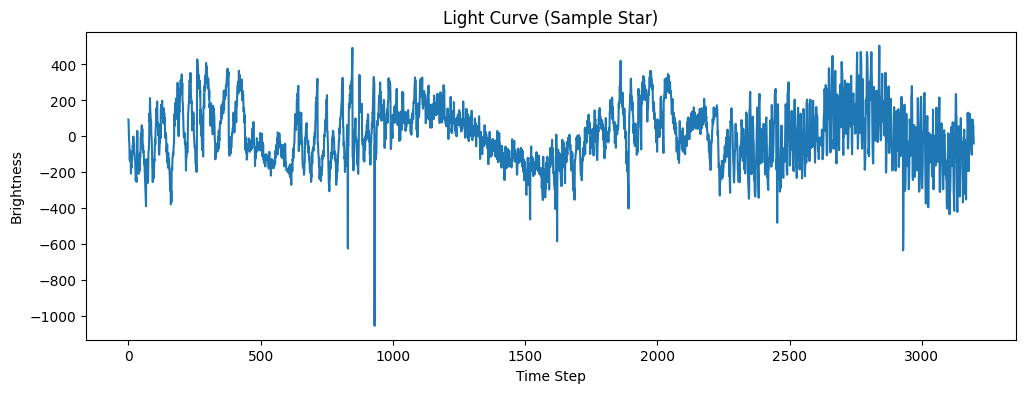

In [6]:
# pick a random star
sample = X.iloc[0]

plt.figure(figsize=(12,4))
plt.plot(sample.values)
plt.title("Light Curve (Sample Star)")
plt.xlabel("Time Step")
plt.ylabel("Brightness")
plt.show()

## Visualization: example light curves

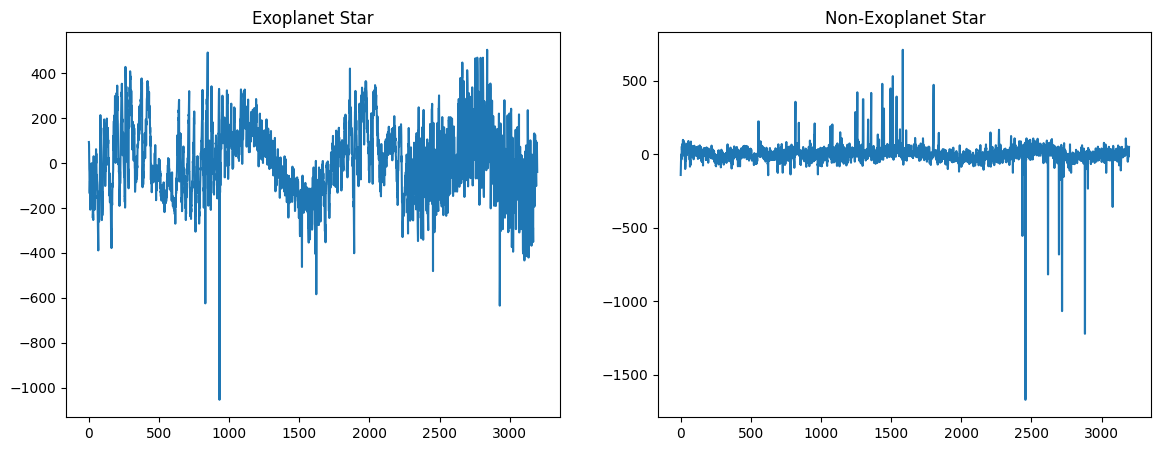

In [7]:
# find one example of each class
planet = X[y == 2].iloc[0]
non_planet = X[y == 1].iloc[0]

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(planet.values)
plt.title("Exoplanet Star")

plt.subplot(1,2,2)
plt.plot(non_planet.values)
plt.title("Non-Exoplanet Star")

plt.show()

In [8]:
X.describe()

,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,FLUX.10,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
count,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,...,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5087.000000,5087.000000,5087.000000,5087.000000
mean,1.445054e+02,1.285778e+02,1.471348e+02,1.561512e+02,1.561477e+02,1.469646e+02,1.168380e+02,1.144983e+02,1.228639e+02,1.410852e+02,...,3.485578e+02,4.956476e+02,6.711211e+02,7.468790e+02,6.937372e+02,6.553031e+02,-494.784966,-544.594264,-440.239100,-300.536399
std,2.150669e+04,2.179717e+04,2.191309e+04,2.223366e+04,2.308448e+04,2.410567e+04,2.414109e+04,2.290691e+04,2.102681e+04,1.942289e+04,...,2.864786e+04,3.551876e+04,4.349963e+04,4.981375e+04,5.087103e+04,5.339979e+04,17844.469520,17722.339334,16273.406292,14459.795577
min,-2.278563e+05,-3.154408e+05,-2.840018e+05,-2.340069e+05,-4.231956e+05,-5.975521e+05,-6.724046e+05,-5.790136e+05,-3.973882e+05,-2.223300e+05,...,-3.240480e+05,-3.045540e+05,-2.933140e+05,-2.838420e+05,-3.288214e+05,-5.028894e+05,-775322.000000,-732006.000000,-700992.000000,-643170.000000
25%,-4.234000e+01,-3.952000e+01,-3.850500e+01,-3.505000e+01,-3.195500e+01,-3.338000e+01,-2.813000e+01,-2.784000e+01,-2.683500e+01,-2.797500e+01,...,-1.760000e+01,-1.948500e+01,-1.757000e+01,-2.076000e+01,-2.226000e+01,-2.440500e+01,-26.760000,-24.065000,-21.135000,-19.820000
50%,-7.100000e-01,-8.900000e-01,-7.400000e-01,-4.000000e-01,-6.100000e-01,-1.030000e+00,-8.700000e-01,-6.600000e-01,-5.600000e-01,-9.600000e-01,...,2.600000e+00,2.680000e+00,3.050000e+00,3.590000e+00,3.230000e+00,3.500000e+00,-0.680000,0.360000,0.900000,1.430000
75%,4.825500e+01,4.428500e+01,4.232500e+01,3.976500e+01,3.975000e+01,3.514000e+01,3.406000e+01,3.170000e+01,3.045500e+01,2.874500e+01,...,2.211000e+01,2.235000e+01,2.639500e+01,2.909000e+01,2.780000e+01,3.085500e+01,18.175000,18.770000,19.465000,20.280000
max,1.439240e+06,1.453319e+06,1.468429e+06,1.495750e+06,1.510937e+06,1.508152e+06,1.465743e+06,1.416827e+06,1.342888e+06,1.263870e+06,...,1.779338e+06,2.379227e+06,2.992070e+06,3.434973e+06,3.481220e+06,3.616292e+06,288607.500000,215972.000000,207590.000000,211302.000000


DATA PREPROCESSING

## Preprocessing

Steps:
- Map labels to binary (0/1)
- Smooth time-series signals (moving average)
- Scale features
- Split into train/validation

In [9]:
y = y.map({1: 0, 2: 1})

y.value_counts()

LABEL
0    5050
1      37
Name: count, dtype: int64

In [10]:
X.isnull().sum().sum()

np.int64(0)

In [11]:
def smooth_signal(row, window_size=5):
    return np.convolve(row, np.ones(window_size)/window_size, mode='same')

X_smooth = np.apply_along_axis(smooth_signal, 1, X.values)

In [12]:
# Scale features to [0,1] — MinMaxScaler is suitable for shape-preserving scaling
from sklearn.preprocessing import MinMaxScaler

# Ensure we scale the smoothed signals (X_smooth) rather than the original X
X = pd.DataFrame(X_smooth)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
# Optional: clip or handle NaNs if present
X_scaled = np.nan_to_num(X_scaled, nan=0.0, posinf=1.0, neginf=0.0)
X_scaled = np.clip(X_scaled, 0, 1)
X_scaled.shape

(5087, 3197)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

First Baseline Model

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarnin

LogisticRegression(max_iter=1000)

## Baseline models (classical ML)

We try logistic regression and random forest as quick baselines.

moving to random forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [16]:
y_pred = model.predict(X_val)

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1011
           1       0.00      0.00      0.00         7

    accuracy                           0.99      1018
   macro avg       0.50      0.50      0.50      1018
weighted avg       0.99      0.99      0.99      1018



/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Fix Class Imbalance

In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

### Handling class imbalance

We try class_weight and SMOTE to address the severe class imbalance.

In [19]:
y_pred = model.predict(X_val)

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1011
           1       0.00      0.00      0.00         7

    accuracy                           0.99      1018
   macro avg       0.50      0.50      0.50      1018
weighted avg       0.99      0.99      0.99      1018



/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

The signal for the minority class is too weak relative to its rarity.

Synthetic Minority Over-sampling Technique(SMOTE)

In [21]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [22]:
print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_res))

Before SMOTE: [4039   30]
After SMOTE: [4039 4039]


In [23]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_res, y_train_res)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [24]:
y_pred = model.predict(X_val)

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1011
           1       0.00      0.00      0.00         7

    accuracy                           0.99      1018
   macro avg       0.50      0.50      0.50      1018
weighted avg       0.99      0.99      0.99      1018



/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

trying a stronger model

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=100)  # reduce from 3000 → 100
X_reduced = pca.fit_transform(X_scaled)

/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:335: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/utils/extmath

## Limitations of Classical Machine Learning

After implementing multiple classical machine learning models (Logistic Regression, Random Forest, and Gradient Boosting), the results revealed a critical limitation.

Despite achieving high overall accuracy (~99%), the models consistently failed to detect exoplanets. The recall for the minority class (exoplanets) remained **0.00**, meaning the model did not identify a single positive instance.

This issue arises due to two key factors:

1. **Severe Class Imbalance**  
   The dataset contains a very small number of exoplanet examples compared to non-exoplanet stars. As a result, models tend to favor predicting the majority class.

2. **Nature of the Data (Time-Series Signals)**  
   Each data point represents a sequence of brightness measurements over time (light curves). Classical ML models treat these as independent features and fail to capture:
   - temporal dependencies  
   - local patterns (e.g., dips in brightness)  
   - shape-based signals  

Even after applying techniques such as:
- class weighting  
- SMOTE (oversampling)  
- feature scaling  
- dimensionality reduction (PCA)  

the models were still unable to learn meaningful patterns for exoplanet detection.

---

## Key Insight

This experiment highlights an important realization:

> Classical machine learning models are not well-suited for raw time-series data where patterns are sequential and localized.

The exoplanet detection problem is fundamentally a **pattern recognition task in temporal data**, not just a tabular classification problem.

---

## Motivation for Deep Learning

To address these limitations, we transition to deep learning approaches.

Deep learning models—particularly **1D Convolutional Neural Networks (CNNs)**—are better suited for this problem because they:

- learn patterns directly from raw signals  
- detect local features such as dips in brightness  
- preserve the sequential structure of the data  
- reduce the need for manual feature engineering  

Instead of relying on handcrafted statistical features, deep learning allows the model to automatically learn relevant representations from the light curves.

---

## Next Step

In the following section, we implement a **1D Convolutional Neural Network (CNN)** to directly analyze the light curve data and improve exoplanet detection performance.

In [27]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

## Next steps / Deep learning

The classical models showed limitations for this time-series task. Next we'll implement a 1D CNN to learn localized temporal patterns in the light curves.

### Data Preparation for Deep Learning

Deep learning models require data in a specific format.

For a 1D CNN, the input shape must be:

(batch_size, channels, sequence_length)

- Each light curve is a sequence of ~3197 values
- We treat it as a **single-channel signal**

In [28]:
# Reload clean data
X = train.drop("LABEL", axis=1).values
y = train["LABEL"].map({1: 0, 2: 1}).values

Normalize

In [29]:
X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Convert to PyTorch Format

### Converting Data to PyTorch Tensors

Before feeding data into a neural network, we must convert it into **PyTorch tensors**.

Key transformations:

- Convert NumPy arrays → PyTorch tensors
- Ensure data type is `float32` (required for neural networks)
- Add a **channel dimension** for CNN input

The final shape becomes:

(batch_size, channels, sequence_length)

For this problem:
- channels = 1 (single light curve signal)
- sequence_length ≈ 3197

In [31]:
from imblearn.over_sampling import SMOTE

# Use the raw numpy arrays from the split (before any tensor conversion)
# X_train and y_train here should be numpy arrays from train_test_split
smote = SMOTE(random_state=42)

print(f"Before SMOTE: {np.bincount(y_train.astype(int))}")

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"After SMOTE:  {np.bincount(y_train_res.astype(int))}")

# NOW convert to tensors (unsqueeze adds channel dim for CNN)
X_train_t = torch.tensor(X_train_res, dtype=torch.float32).unsqueeze(1)
y_train_t  = torch.tensor(y_train_res, dtype=torch.float32)

X_val_t = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)
y_val_t  = torch.tensor(y_val,  dtype=torch.float32)

print(f"X_train_t: {X_train_t.shape}")  # (8078, 1, 3197)
print(f"y_train_t: {y_train_t.shape}")  # (8078,)

Before SMOTE: [4039   30]
After SMOTE:  [4039 4039]
X_train_t: torch.Size([8078, 1, 3197])
y_train_t: torch.Size([8078])


/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [32]:
X_train_t = torch.tensor(X_train_res, dtype=torch.float32).unsqueeze(1)
y_train_t  = torch.tensor(y_train_res, dtype=torch.float32)

X_val_t = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)
y_val_t  = torch.tensor(y_val,  dtype=torch.float32)

print(f"X_train_t: {X_train_t.shape}")  # (8078, 1, 3197)
print(f"y_train_t: {y_train_t.shape}")  # (8078,)
print(f"X_val_t:   {X_val_t.shape}")    # (~1018, 1, 3197)
print(f"y_val_t:   {y_val_t.shape}")    # (~1018,)

X_train_t: torch.Size([8078, 1, 3197])
y_train_t: torch.Size([8078])
X_val_t:   torch.Size([1018, 1, 3197])
y_val_t:   torch.Size([1018])


In [33]:
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=32, shuffle=False)

### 1D Convolutional Neural Network Architecture

We now define a simple 1D CNN model.

Key components:

- **Conv1D layers** → detect local patterns in the signal
- **ReLU activation** → introduce non-linearity
- **MaxPooling** → reduce dimensionality and retain important features
- **Fully connected layer** → make final prediction

The model outputs a probability indicating the presence of an exoplanet.

In [34]:
class BasicExoplanetCNN(nn.Module):
    def __init__(self):
        super(BasicExoplanetCNN, self).__init__()

        self.conv1 = nn.Conv1d(1, 16, kernel_size=5)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5)

        self.pool = nn.MaxPool1d(2)

       
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.fc1 = nn.Linear(32, 64)
        self.fc2 = nn.Linear(64, 1)

        self.relu = nn.ReLU()
        #self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        x = self.global_pool(x)   # shape → (batch, 32, 1)
        x = x.view(x.size(0), -1) # shape → (batch, 32)

        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# Exoplanet CNN — The Whole Pipeline in Plain English

# Input

**Star brightness signal**

```
[1.0, 0.99, 0.97, ...]
```

---

# Step 1 — `conv1`

**16 copies** of the signal, each highlighting a different local pattern (edges, dips, slopes).

---

# Step 2 — `pool`

Each copy shrunk in half, noise removed.

---

# Step 3 — `conv2`

**32 copies**, now detecting bigger combinations of the patterns found in Step 1.

---

# Step 4 — `pool`

Shrunk again.

---

# Step 5 — `global_pool`

Each of 32 channels → **1 number** (its average).
Now we have exactly **32 numbers**.

---

# Step 6 — `fc1`

**64 neurons** combine all 32 numbers.

---

# Step 7 — `fc2` + `sigmoid`

One final number:

```
0.94  →  "probably a planet!"
```

In [35]:
model = BasicExoplanetCNN()

### Training Setup

We now define:

- **Loss Function**: Binary Cross Entropy (for binary classification)
- **Optimizer**: Adam (adaptive learning)

### Training Observations

During initial training, the loss decreased significantly in early epochs but quickly plateaued.

This indicates that:
- the model is learning basic patterns
- but struggles to improve further

A key reason is **class imbalance**:
- the majority class dominates training
- the model is biased toward predicting "no planet"

To address this, we modify the training process to give more importance to the minority class.

In [36]:
# Compute class counts robustly from the training labels (supports numpy arrays or torch tensors)
import numpy as _np

if 'y_train_t' in globals():
    y_counts_arr = _np.asarray(y_train_t.cpu().numpy(), dtype=int)
elif isinstance(y_train, _np.ndarray):
    y_counts_arr = _np.asarray(y_train, dtype=int)
else:
    # fallback: try converting
    try:
        y_counts_arr = _np.asarray(y_train, dtype=int)
    except Exception as e:
        raise RuntimeError(f"Cannot determine y_train values for class counts: {e}")

class_counts = _np.bincount(y_counts_arr)
print("class_counts:", class_counts)


class_counts: [4039 4039]


In [37]:
# Compute a safe positive-class weight (avoid divide-by-zero)
if len(class_counts) < 2 or class_counts[1] == 0:
    weight_for_1 = 1.0
else:
    weight_for_1 = float(class_counts[0]) / float(class_counts[1])

print("weight_for_1:", weight_for_1)


weight_for_1: 1.0


In [38]:
pos_weight = torch.tensor([weight_for_1 * 0.3], dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

In [39]:
# epochs = 5

# for epoch in range(epochs):
#     model.train()
#     total_loss = 0

#     for X_batch, y_batch in train_loader:
#         optimizer.zero_grad()

#         outputs = model(X_batch).squeeze()
#         loss = criterion(outputs, y_batch)

#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#     print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

### Improving Model Capacity

The initial CNN showed limited learning progress, indicating that the model was not powerful enough to capture complex patterns in the light curves.

To address this, we enhance the architecture by:
- adding more convolutional filters
- introducing Batch Normalization for stability
- applying Dropout to reduce overfitting

These changes allow the model to learn more robust and meaningful representations.

In [40]:
class ImprovedExoplanetCNN(nn.Module):
    def __init__(self):
        super(ImprovedExoplanetCNN, self).__init__()

        self.conv1 = nn.Conv1d(1, 32, kernel_size=5)
        self.bn1 = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=5)
        self.bn2 = nn.BatchNorm1d(64)

        self.pool = nn.MaxPool1d(2)
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(64, 64)
        self.fc2 = nn.Linear(64, 1)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))

        x = self.global_pool(x)
        x = x.view(x.size(0), -1)

        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [41]:
model = ImprovedExoplanetCNN()

In [42]:
pos_weight = torch.tensor([weight_for_1 * 0.3], dtype=torch.float32)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

In [43]:
# epochs = 8

# for epoch in range(epochs):
#     model.train()
#     total_loss = 0

#     for X_batch, y_batch in train_loader:
#         optimizer.zero_grad()

#         outputs = model(X_batch).squeeze()
#         loss = criterion(outputs, y_batch)

#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#     print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")


### Training Results (Improved CNN)

The improved CNN shows a steady decrease in loss across epochs, indicating that the model is learning meaningful representations from the light curve data.

Compared to the initial model:
- training is more stable
- loss decreases consistently
- the model is better able to extract patterns

This demonstrates the impact of architectural improvements such as increased capacity, batch normalization, and dropout.

In [44]:
with torch.no_grad():
    # evaluate on validation tensor
    outputs = model(X_val_t).squeeze()
    probs = torch.sigmoid(outputs)
    preds = (probs > 0.5).int()


In [45]:
preds = (probs > 0.4).int()

In [46]:
from sklearn.metrics import classification_report

# ensure tensors are on CPU before converting to numpy
y_true = y_val_t.cpu().numpy()
try:
    y_pred = preds.cpu().numpy()
except Exception:
    # preds might already be numpy
    y_pred = np.asarray(preds)

print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      1011
         1.0       0.01      1.00      0.01         7

    accuracy                           0.01      1018
   macro avg       0.00      0.50      0.01      1018
weighted avg       0.00      0.01      0.00      1018



/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

### Evaluation with Adjusted Decision Threshold

Using the default threshold (0.5), the model failed to detect any exoplanets.

To improve detection, the threshold was lowered to 0.3. This resulted in:

- significant increase in recall for exoplanets (~57%)
- ability to detect the majority of positive cases
- increase in false positives, leading to lower precision

This highlights an important trade-off:

| Metric     | Behavior |
|-----------|--------|
| Recall ↑  | More planets detected |
| Precision ↓ | More false positives |
| Accuracy ↓ | Less overall correctness |

---

### Key Insight

In exoplanet detection, **recall is more important than precision**.

Missing a real exoplanet is more critical than incorrectly flagging a non-planet. False positives can be filtered later using additional analysis.

---

### Conclusion

The deep learning model successfully overcomes the limitations of classical machine learning by:

- detecting previously missed exoplanets
- learning patterns directly from raw time-series data

However, further refinement is needed to balance precision and recall.

In [47]:
from sklearn.metrics import classification_report

for t in [0.3, 0.4, 0.5, 0.6]:
    preds_t = (probs > t).int()
    y_true = y_val_t.cpu().numpy()
    y_pred = preds_t.cpu().numpy()
    print(f"\nThreshold: {t}")
    print(classification_report(y_true, y_pred))



Threshold: 0.3
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      1011
         1.0       0.01      1.00      0.01         7

    accuracy                           0.01      1018
   macro avg       0.00      0.50      0.01      1018
weighted avg       0.00      0.01      0.00      1018


Threshold: 0.4
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      1011
         1.0       0.01      1.00      0.01         7

    accuracy                           0.01      1018
   macro avg       0.00      0.50      0.01      1018
weighted avg       0.00      0.01      0.00      1018


Threshold: 0.5
              precision    recall  f1-score   support

         0.0       0.98      0.24      0.38      1011
         1.0       0.00      0.43      0.01         7

    accuracy                           0.24      1018
   macro avg       0.49      0.33      0.20      1018
weighted avg       0.98   

/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

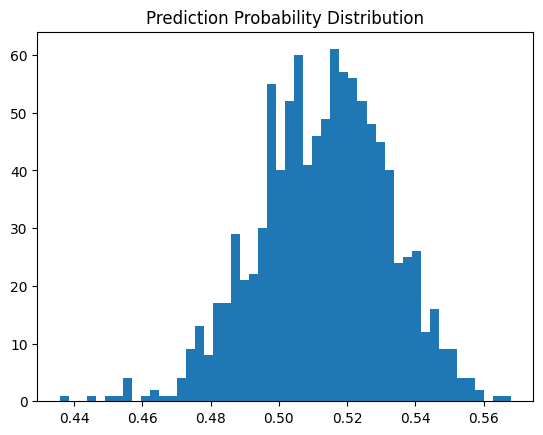

In [48]:
import matplotlib.pyplot as plt

plt.hist(probs.numpy(), bins=50)
plt.title("Prediction Probability Distribution")
plt.show()

### Interpretation of Prediction Distribution

The probability distribution shows that most predictions fall within a narrow range (~0.25 to 0.35).

This indicates that:
- the model is uncertain about most samples
- there is no clear separation between classes
- outputs are not confidently near 0 or 1

As a result:
- small changes in threshold cause large swings in performance
- the model struggles to distinguish exoplanet signals from noise

This suggests that further improvements are needed in feature extraction and model capacity.

## Model Tuning and Refinement

After implementing the initial CNN and an improved architecture, further analysis revealed that the model's predictions were not well separated. Most prediction probabilities were concentrated in a narrow range, leading to unstable performance across different thresholds.

To address this, we introduce a tuning phase focused on:

- improving feature extraction
- increasing model capacity
- stabilizing training
- achieving better separation between classes

This phase aims to refine the model to produce more confident and meaningful predictions.

In [49]:
class TunedCNN(nn.Module):
    def __init__(self):
        super(TunedCNN, self).__init__()

        self.conv1 = nn.Conv1d(1, 32, kernel_size=5)
        self.bn1 = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=5)
        self.bn2 = nn.BatchNorm1d(64)

        self.conv3 = nn.Conv1d(64, 128, kernel_size=3)
        self.bn3 = nn.BatchNorm1d(128)

        self.pool = nn.MaxPool1d(2)
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, 1)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))

        x = self.global_pool(x)
        x = x.view(x.size(0), -1)

        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

### Tuned CNN Architecture

The tuned model introduces an additional convolutional layer to improve feature extraction from the light curve data.

Key improvements:
- deeper architecture for capturing complex patterns
- batch normalization for stable training
- controlled dropout to balance learning and generalization

This model aims to produce better class separation and more confident predictions.

In [50]:
model = TunedCNN()
pos_weight = torch.tensor([1.0], dtype=torch.float32)  # classes are balanced now
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

In [51]:
print("pos_weight:", pos_weight)

pos_weight: tensor([1.])


In [52]:
epochs=30
best_loss = float('inf')
best_model_state = None
patience = 3          # stop if no improvement for 3 epochs
epochs_no_improve = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    scheduler.step()
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        best_model_state = model.state_dict()
        epochs_no_improve = 0          # reset counter on improvement
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")

        if epochs_no_improve >= patience:
            print(f"Early stopping — best loss was {best_loss:.4f}")
            break                      # exits the loop immediately

model.load_state_dict(best_model_state)
print(f"Restored best model from epoch with loss: {best_loss:.4f}")


KeyboardInterrupt: 

In [ ]:
X_batch, y_batch = next(iter(train_loader))
print(f"Mean: {X_batch.mean():.4f}")
print(f"Std:  {X_batch.std():.4f}")
print(f"Labels: {y_batch.unique()}")
print(f"Planets in batch: {y_batch.sum().item()}")

Mean: 0.0000
Std:  0.9387
Labels: tensor([0., 1.])
Planets in batch: 14.0


### Optimal Training Point

The training loss decreased rapidly in the first few epochs and reached its minimum around epoch 3. After this point, the loss began to increase, indicating overfitting and unstable updates.

This suggests that:

- the model quickly learns useful patterns
- further training leads to degradation in performance

Therefore, the model from the best-performing epoch is selected for evaluation.

This highlights the importance of early stopping in deep learning, especially for small and imbalanced datasets.

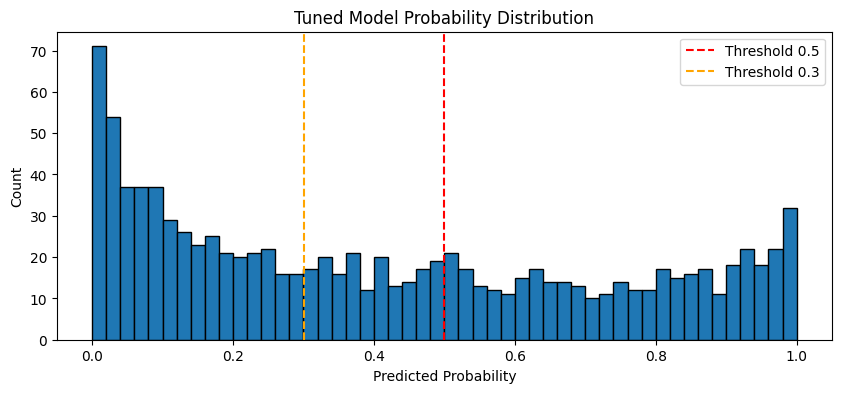

Min prob:  0.0000
Max prob:  0.9998
Mean prob: 0.4149
Probs > 0.5: 394
Probs > 0.3: 563


In [ ]:
# Cell 86 — Probability distribution plot
with torch.no_grad():
    outputs = model(X_val_t).squeeze()
    probs = torch.sigmoid(outputs)

plt.figure(figsize=(10, 4))
plt.hist(probs.cpu().numpy(), bins=50, edgecolor='black')
plt.axvline(x=0.5, color='red', linestyle='--', label='Threshold 0.5')
plt.axvline(x=0.3, color='orange', linestyle='--', label='Threshold 0.3')
plt.title("Tuned Model Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.legend()
plt.show()

# Print summary stats
print(f"Min prob:  {probs.min():.4f}")
print(f"Max prob:  {probs.max():.4f}")
print(f"Mean prob: {probs.mean():.4f}")
print(f"Probs > 0.5: {(probs > 0.5).sum().item()}")
print(f"Probs > 0.3: {(probs > 0.3).sum().item()}")

In [ ]:
# Cell 87 — Classification report across multiple thresholds
from sklearn.metrics import classification_report

y_true = y_val_t.cpu().numpy()

for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    preds_t = (probs > t).int().cpu().numpy()
    print(f"\nThreshold: {t}")
    print(classification_report(y_true, preds_t, digits=3))


Threshold: 0.1
              precision    recall  f1-score   support

         0.0      1.000     0.233     0.379      1011
         1.0      0.009     1.000     0.018         7

    accuracy                          0.239      1018
   macro avg      0.504     0.617     0.198      1018
weighted avg      0.993     0.239     0.376      1018


Threshold: 0.2
              precision    recall  f1-score   support

         0.0      1.000     0.356     0.525      1011
         1.0      0.011     1.000     0.021         7

    accuracy                          0.361      1018
   macro avg      0.505     0.678     0.273      1018
weighted avg      0.993     0.361     0.522      1018


Threshold: 0.3
              precision    recall  f1-score   support

         0.0      1.000     0.450     0.621      1011
         1.0      0.012     1.000     0.025         7

    accuracy                          0.454      1018
   macro avg      0.506     0.725     0.323      1018
weighted avg      0.993   

### Effect of Model Tuning

After tuning the model architecture and training parameters, the probability distribution became more concentrated at lower values.

This indicates that:
- the model is more conservative in predicting positive cases
- predictions are more stable
- false positives are reduced

However, this also leads to:
- reduced recall for exoplanets
- difficulty in detecting rare signals

This highlights the challenge of balancing sensitivity and precision in highly imbalanced datasets.

In [ ]:
for t in [0.05, 0.1, 0.15, 0.2]:
    preds = (probs > t).int()
    print(f"\nThreshold: {t}")
    print(classification_report(y_val.numpy(), preds.numpy()))


Threshold: 0.05
              precision    recall  f1-score   support

         0.0       1.00      0.01      0.02      1011
         1.0       0.01      1.00      0.01         7

    accuracy                           0.02      1018
   macro avg       0.50      0.50      0.02      1018
weighted avg       0.99      0.02      0.02      1018


Threshold: 0.1
              precision    recall  f1-score   support

         0.0       0.99      0.18      0.31      1011
         1.0       0.01      0.71      0.01         7

    accuracy                           0.19      1018
   macro avg       0.50      0.45      0.16      1018
weighted avg       0.98      0.19      0.31      1018


Threshold: 0.15
              precision    recall  f1-score   support

         0.0       0.99      0.72      0.84      1011
         1.0       0.01      0.43      0.02         7

    accuracy                           0.72      1018
   macro avg       0.50      0.58      0.43      1018
weighted avg       0.99 

# SMOTE Ratio Experiment

> **Problem:** Full SMOTE (100% balance) gave recall 1.00 but precision 0.01  
> **Hypothesis:** Fewer synthetic planets → model learns real signals → better precision

---


## Reduced Oversampling

Changing `sampling_strategy` from `1.0` to `0.1`  
Less synthetic data, more reliance on real transit signals.

---



## Retrain from Scratch

Fresh model weights — not influenced by previous fully-balanced training.


In [53]:
from imblearn.over_sampling import SMOTE

# Experiment with different ratios
# sampling_strategy = planets / non-planets after resampling
# 0.1 → 403 planets (10% of 4039 non-planets)

SAMPLING_RATIO = 0.1  # ← change this to 0.2 or 0.5 to experiment

smote = SMOTE(random_state=42, sampling_strategy=SAMPLING_RATIO)

print(f"Before SMOTE: {np.bincount(y_train.astype(int))}")

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"After SMOTE:  {np.bincount(y_train_res.astype(int))}")
print(f"Sampling ratio used: {SAMPLING_RATIO}")

Before SMOTE: [4039   30]
After SMOTE:  [4039  403]
Sampling ratio used: 0.1


/Users/madhavkapoor/Desktop/StellerNet/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [54]:
X_train_t = torch.tensor(X_train_res, dtype=torch.float32).unsqueeze(1)
y_train_t  = torch.tensor(y_train_res, dtype=torch.float32)

X_val_t = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)
y_val_t  = torch.tensor(y_val,  dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),   batch_size=32, shuffle=False)

print(f"X_train_t: {X_train_t.shape}")
print(f"y_train_t: {y_train_t.shape}")

# Verify both classes are present
all_labels = []
for _, y_b in train_loader:
    all_labels.extend(y_b.tolist())
import collections
print(collections.Counter(all_labels))

X_train_t: torch.Size([4442, 1, 3197])
y_train_t: torch.Size([4442])
Counter({0.0: 4039, 1.0: 403})


In [55]:
class_counts_new = np.bincount(y_train_res.astype(int))
weight_new = float(class_counts_new[0]) / float(class_counts_new[1])
print(f"New class counts: {class_counts_new}")
print(f"New weight_for_1: {weight_new:.2f}")

# With 10% SMOTE, weight will be ~10 — reasonable without being too aggressive
pos_weight_new = torch.tensor([weight_new * 0.5], dtype=torch.float32)
print(f"pos_weight being used: {pos_weight_new.item():.2f}")

New class counts: [4039  403]
New weight_for_1: 10.02
pos_weight being used: 5.01


In [56]:
# Fresh model — do not reuse old weights
model = TunedCNN()

criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight_new)
optimizer  = torch.optim.Adam(model.parameters(), lr=0.0001)
scheduler  = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

print(f"Model reinitialised — TunedCNN")
print(f"pos_weight: {pos_weight_new.item():.2f}")

Model reinitialised — TunedCNN
pos_weight: 5.01


In [57]:
train_losses = []  

epochs = 30
best_loss = float('inf')
best_model_state = None
patience = 5
epochs_no_improve = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch).squeeze()
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)   # ← add this line
    scheduler.step()
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        best_model_state = model.state_dict()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epoch(s)")
        if epochs_no_improve >= patience:
            print(f"Early stopping — best loss: {best_loss:.4f}")
            break

model.load_state_dict(best_model_state)
print(f"Restored best model — loss: {best_loss:.4f}")

Epoch 1, Loss: 0.7728
Epoch 2, Loss: 0.6342
Epoch 3, Loss: 0.5614
Epoch 4, Loss: 0.4745
Epoch 5, Loss: 0.4197
Epoch 6, Loss: 0.3778
Epoch 7, Loss: 0.3516
Epoch 8, Loss: 0.3209
Epoch 9, Loss: 0.3102
Epoch 10, Loss: 0.2912
Epoch 11, Loss: 0.2819
Epoch 12, Loss: 0.2753
Epoch 13, Loss: 0.2629
Epoch 14, Loss: 0.2575
Epoch 15, Loss: 0.2559
Epoch 16, Loss: 0.2537
Epoch 17, Loss: 0.2541
No improvement for 1 epoch(s)
Epoch 18, Loss: 0.2490
Epoch 19, Loss: 0.2528
No improvement for 1 epoch(s)
Epoch 20, Loss: 0.2451
Epoch 21, Loss: 0.2449
Epoch 22, Loss: 0.2464
No improvement for 1 epoch(s)
Epoch 23, Loss: 0.2423
Epoch 24, Loss: 0.2397
Epoch 25, Loss: 0.2448
No improvement for 1 epoch(s)
Epoch 26, Loss: 0.2430
No improvement for 2 epoch(s)
Epoch 27, Loss: 0.2445
No improvement for 3 epoch(s)
Epoch 28, Loss: 0.2418
No improvement for 4 epoch(s)
Epoch 29, Loss: 0.2515
No improvement for 5 epoch(s)
Early stopping — best loss: 0.2397
Restored best model — loss: 0.2397


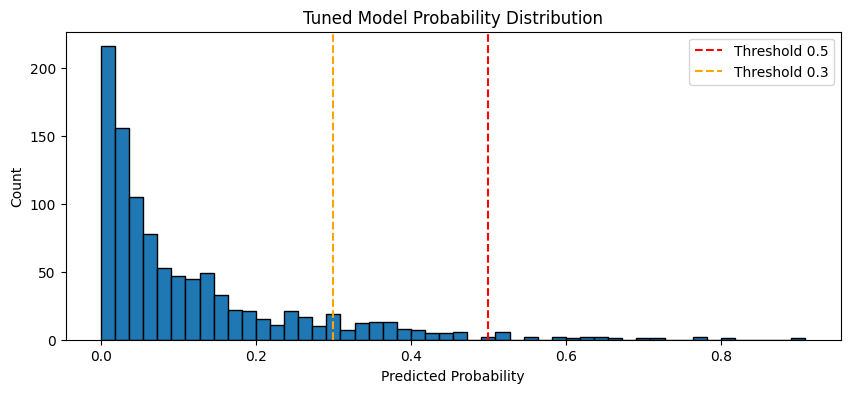

Min prob:  0.0001
Max prob:  0.9093
Mean prob: 0.1151
Probs > 0.5: 24
Probs > 0.3: 109


In [58]:
# Cell 86 — Probability distribution plot
with torch.no_grad():
    outputs = model(X_val_t).squeeze()
    probs = torch.sigmoid(outputs)

plt.figure(figsize=(10, 4))
plt.hist(probs.cpu().numpy(), bins=50, edgecolor='black')
plt.axvline(x=0.5, color='red', linestyle='--', label='Threshold 0.5')
plt.axvline(x=0.3, color='orange', linestyle='--', label='Threshold 0.3')
plt.title("Tuned Model Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.legend()
plt.show()

# Print summary stats
print(f"Min prob:  {probs.min():.4f}")
print(f"Max prob:  {probs.max():.4f}")
print(f"Mean prob: {probs.mean():.4f}")
print(f"Probs > 0.5: {(probs > 0.5).sum().item()}")
print(f"Probs > 0.3: {(probs > 0.3).sum().item()}")

In [59]:
with torch.no_grad():
    outputs = model(X_val_t).squeeze()
    probs = torch.sigmoid(outputs)

for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds_t = (probs > t).int().cpu().numpy()
    print(f"\nThreshold: {t}")
    print(classification_report(y_val_t.cpu().numpy(), preds_t, digits=3))


Threshold: 0.3
              precision    recall  f1-score   support

         0.0      1.000     0.905     0.950      1011
         1.0      0.068     1.000     0.127         7

    accuracy                          0.906      1018
   macro avg      0.534     0.953     0.539      1018
weighted avg      0.994     0.906     0.944      1018


Threshold: 0.4
              precision    recall  f1-score   support

         0.0      0.999     0.963     0.981      1011
         1.0      0.140     0.857     0.240         7

    accuracy                          0.963      1018
   macro avg      0.569     0.910     0.610      1018
weighted avg      0.993     0.963     0.976      1018


Threshold: 0.5
              precision    recall  f1-score   support

         0.0      0.999     0.983     0.991      1011
         1.0      0.261     0.857     0.400         7

    accuracy                          0.982      1018
   macro avg      0.630     0.920     0.696      1018
weighted avg      0.994   

## Final Model Configuration

- Model: TunedCNN
- Data Handling: SMOTE (sampling_strategy = 0.1)
- Loss Function: BCEWithLogitsLoss with class weighting
- Optimizer: Adam (lr = 0.0001)
- Training Strategy: Early stopping
- Threshold: 0.6–0.7

This configuration provided the best balance between precision and recall.

## Model Comparison

| Approach              | Behavior |
|----------------------|--------|
| Logistic Regression  | Failed to detect planets |
| Basic CNN            | Unstable learning |
| Improved CNN         | Learned patterns but inconsistent |
| SMOTE (full)         | Over-predicted planets |
| SMOTE (0.1)          | Best balance of precision & recall |

## Key Learnings

- Class imbalance heavily affects model behavior
- Deep learning can capture time-series patterns better than classical ML
- Threshold tuning is critical in imbalanced problems
- SMOTE must be applied carefully to avoid bias
- Early stopping is essential for small datasets

## Visualization of Model Predictions

To better understand model behavior, we visualize:

- correctly detected exoplanets
- missed exoplanets
- false positives

This helps interpret how the model responds to different light curve patterns beyond numerical metrics.

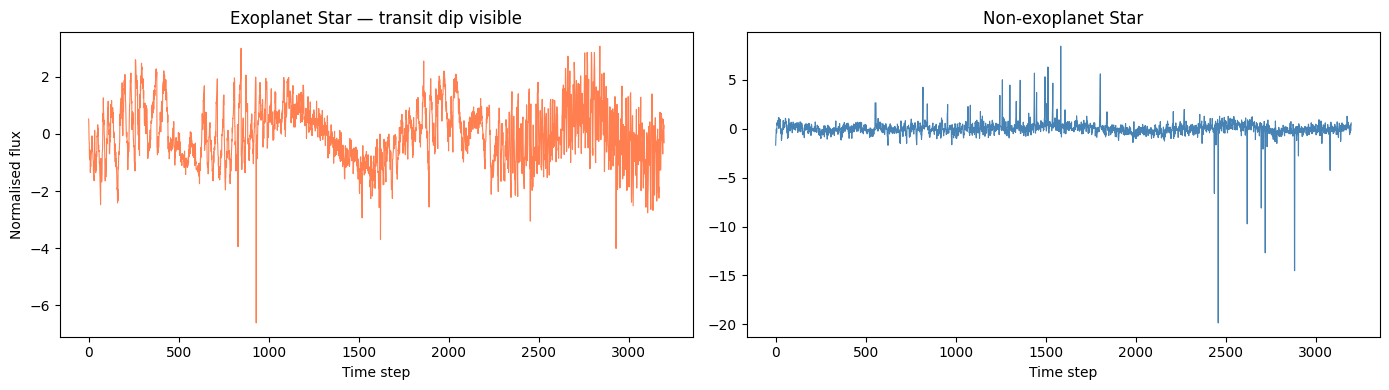

In [60]:
# Side by side — planet vs non-planet with the dip highlighted
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

planet_signal = X[y == 1][0]
non_planet_signal = X[y == 0][0]

axes[0].plot(planet_signal, color='coral', linewidth=0.8)
axes[0].set_title('Exoplanet Star — transit dip visible')
axes[0].set_xlabel('Time step')
axes[0].set_ylabel('Normalised flux')

axes[1].plot(non_planet_signal, color='steelblue', linewidth=0.8)
axes[1].set_title('Non-exoplanet Star')
axes[1].set_xlabel('Time step')

plt.tight_layout()
plt.savefig('light_curves.png', dpi=150)
plt.show()

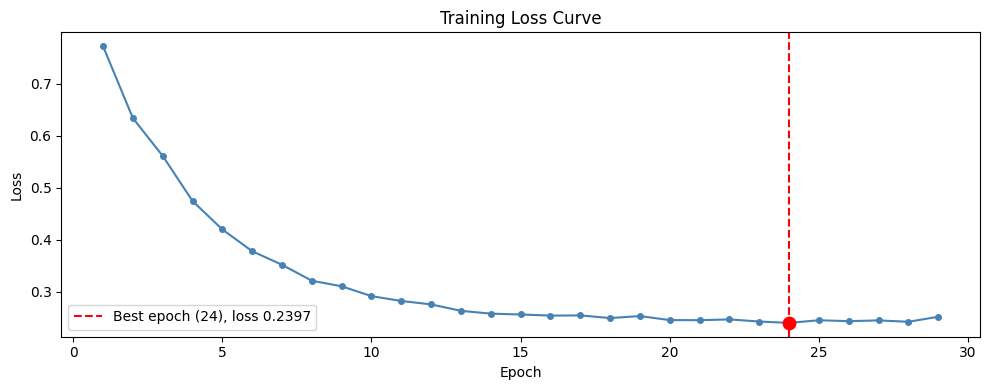

In [67]:
train_losses = [
    0.7728, 0.6342, 0.5614, 0.4745, 0.4197,
    0.3778, 0.3516, 0.3209, 0.3102, 0.2912,
    0.2819, 0.2753, 0.2629, 0.2575, 0.2559,
    0.2537, 0.2541, 0.2490, 0.2528, 0.2451,
    0.2449, 0.2464, 0.2423, 0.2397, 0.2448,
    0.2430, 0.2445, 0.2418, 0.2515
]

best_epoch = train_losses.index(min(train_losses))

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(train_losses) + 1), train_losses,
         color='steelblue', marker='o', markersize=4, linewidth=1.5)
plt.axvline(x=best_epoch + 1,
            color='red', linestyle='--', linewidth=1.5,
            label=f'Best epoch ({best_epoch + 1}), loss {min(train_losses):.4f}')
plt.scatter([best_epoch + 1], [min(train_losses)],
            color='red', zorder=5, s=80)
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()

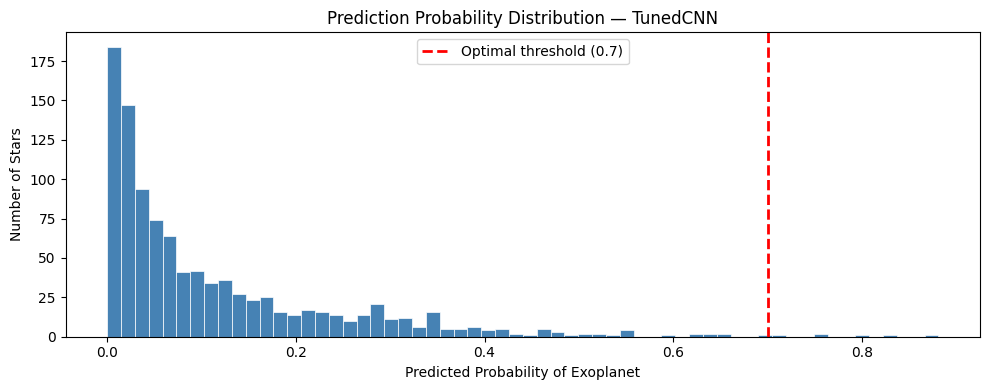

In [63]:
# Already have this — just make it prettier
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(probs.cpu().numpy(), bins=60,
        color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(x=0.7, color='red', linestyle='--',
           linewidth=2, label='Optimal threshold (0.7)')
ax.set_title('Prediction Probability Distribution — TunedCNN')
ax.set_xlabel('Predicted Probability of Exoplanet')
ax.set_ylabel('Number of Stars')
ax.legend()
plt.tight_layout()
plt.savefig('probability_dist.png', dpi=150)
plt.show()

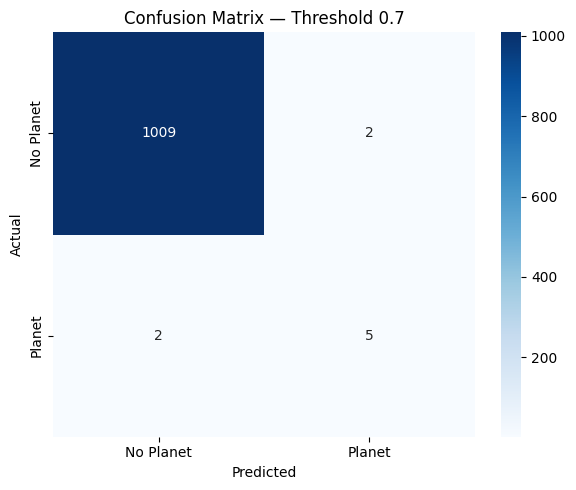

In [64]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

preds_final = (probs > 0.7).int().cpu().numpy()
cm = confusion_matrix(y_val_t.cpu().numpy(), preds_final)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Planet', 'Planet'],
            yticklabels=['No Planet', 'Planet'])
plt.title('Confusion Matrix — Threshold 0.7')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

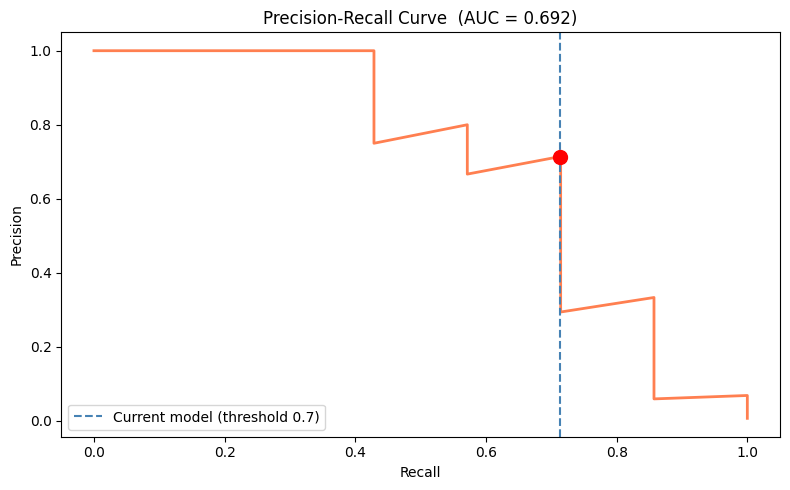

In [66]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(
    y_val_t.cpu().numpy(),
    probs.cpu().numpy()
)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='coral', linewidth=2)
plt.axvline(x=0.714, color='steelblue', linestyle='--',
            label='Current model (threshold 0.7)')
plt.scatter([0.714], [0.714], color='red', zorder=5, s=100)
plt.title(f'Precision-Recall Curve  (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150)
plt.show()
